In [20]:
import pandas as pd
import numpy as np
import seaborn as sns  
import matplotlib.pyplot as plt 
from scipy.stats import pearsonr, normaltest

In [2]:
df = pd.read_csv("/Users/tomchege/Documents/machine_learning_assignment/data/job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None


In [4]:
# 1. Calculate Q1, Q3, and IQR
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify outliers
outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

# 4. Central Tendencies
max_salary = df["salary"].max()
min_salary = df["salary"].min()

median_salary = df["salary"].median()  
mean_salary = df["salary"].mean()
mode_salary = df["salary"].mode()

# 5. Display results
print("-" * 50)
print("OUTLIER DETECTION REPORT: SALARY")
print("-" * 50)
print(f"Column: {'salary'}")
print(f"Q1 (25th percentile):      ${Q1:>12,.2f}")
print(f"Q3 (75th percentile):      ${Q3:>12,.2f}")
print(f"IQR:                       ${IQR:>12,.2f}")
print(f"Lower Bound:               ${lower_bound:>12,.2f}")
print(f"Upper Bound:               ${upper_bound:>12,.2f}")
print("-" * 50)
print(f"Number of outliers found:  {len(outliers)}")
print("-" * 50)
print('')
print("Central Tendency")
print("-" * 50)
print(f"Largest Salary:            ${max_salary:>12,.2f}")
print(f"Smallest Salary:           ${min_salary:>12,.2f}")
print(f"Median:                    ${median_salary:>12,.2f}")
print(f"Mean:                      ${mean_salary:>12,.2f}") 

print('')
print("-" * 50)
print("Distribution")
print("-" * 50)

# Calculate the difference percentage to be precise
diff_percent = abs(mean_salary - median_salary) / median_salary * 100

print(f"Mean:   ${mean_salary:>12,.2f}")
print(f"Median: ${median_salary:>12,.2f}")
print(f"Difference: {diff_percent:.4f}%")
print("-" * 50)

if abs(mean_salary - median_salary) < (median_salary * 0.05): # Less than 5% difference
    print("RESULT: SYMMETRIC (NORMAL) DISTRIBUTION")
    print("  - The Mean and Median are nearly identical.")
    print("  - The data is likely balanced around the center.")
    print("  - No significant skewness detected.")
elif mean_salary > median_salary:
    print("RESULT: RIGHT SKEWED (POSITIVE SKEW)")
    print("  - The Mean is pulled higher by a few large salaries.")
    print("  - The 'tail' extends to the right.")
else:
    print("RESULT: LEFT SKEWED (NEGATIVE SKEW)")
    print("  - The Mean is pulled lower by a few small salaries.")
    print("  - The 'tail' extends to the left.")

print("-" * 50)

--------------------------------------------------
OUTLIER DETECTION REPORT: SALARY
--------------------------------------------------
Column: salary
Q1 (25th percentile):      $  119,358.00
Q3 (75th percentile):      $  169,492.00
IQR:                       $   50,134.00
Lower Bound:               $   44,157.00
Upper Bound:               $  244,693.00
--------------------------------------------------
Number of outliers found:  2336
--------------------------------------------------

Central Tendency
--------------------------------------------------
Largest Salary:            $  333,046.00
Smallest Salary:           $   31,867.00
Median:                    $  143,453.00
Mean:                      $  145,718.08

--------------------------------------------------
Distribution
--------------------------------------------------
Mean:   $  145,718.08
Median: $  143,453.00
Difference: 1.5790%
--------------------------------------------------
RESULT: SYMMETRIC (NORMAL) DISTRIBUTION
  - The

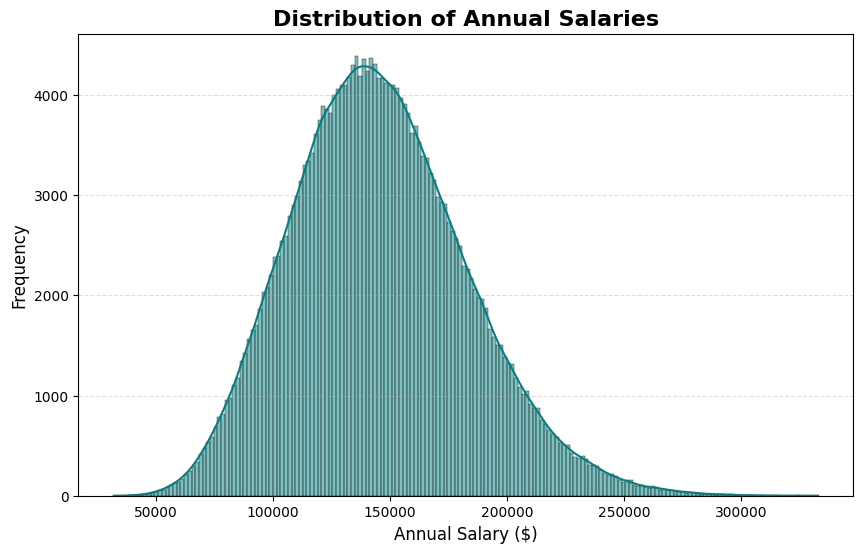

In [5]:
# Examine the distribution of the target variable, salary. 
# Is it symmetric, skewed, or does it show any unusual patterns (e.g. multiple peaks, gaps, outliers)?
# Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], kde=True, color='teal')
plt.title('Distribution of Annual Salaries', fontsize=16, fontweight='bold')
plt.xlabel('Annual Salary ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Conclusion: 
The histogram reveals that salaries are right-skewed, with a concentration of roles earning between 
$60k and $100k. A long tail extends to the right, indicating a smaller number of high-earning positions 
(likely Senior or specialized roles). The KDE line confirms the unimodal nature of the distribution, 
suggesting most employees fall within a standard pay band, with outliers representing executive or 
highly specialized technical roles.

## Examine the distribution of experience_years. 
#### How are experience levels spread across the workforce represented in this dataset?
Data Type: Discrete Numeric
Best Visualization: Bar Plot (if distinct integer values are few).
Justification: Since experience is discrete (e.g., 1, 2, 3 years), a bar plot shows the exact count for each year clearly. 

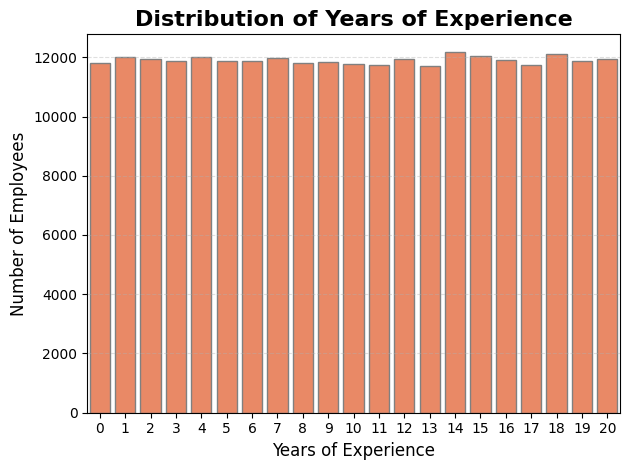

In [6]:
sns.barplot(
    x=df['experience_years'].value_counts().sort_index().index, 
    y=df['experience_years'].value_counts().sort_index().values,
    color='coral',
    edgecolor='grey',  
    linewidth=1
)

plt.title('Distribution of Years of Experience', fontsize=16, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

DISTRIBUTION ANALYSIS: Years of Experience

Observation : Uniform Distribution

- All bars hover around 11,500-12,200 employees
- No dramatic peaks or valleys
- Experience levels from 0-20 years are nearly equally represented
- No Natural "Career Drop-off"


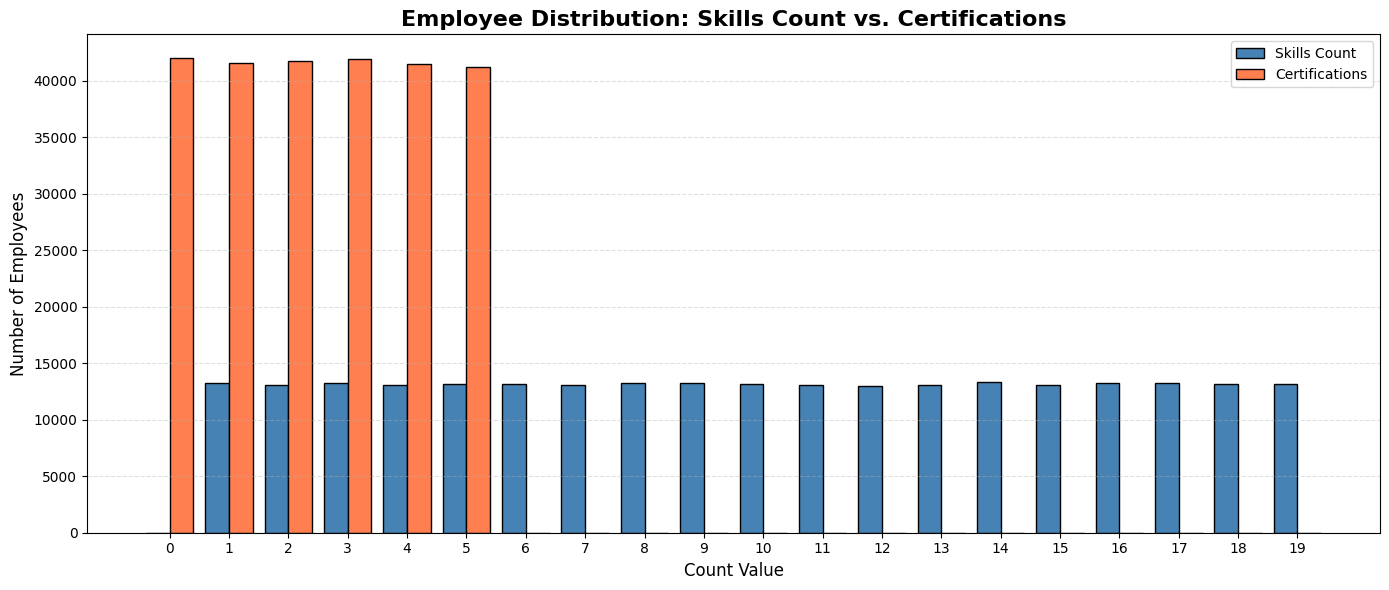

In [7]:
# Examine the distributions of skills_count and certifications. 
# Do most employees cluster around particular values, or are these fairly evenly spread?

# Create a figure with two subplots
# Get value counts and sort by the numeric key
skills_counts = df['skills_count'].value_counts().sort_index()
cert_counts = df['certifications'].value_counts().sort_index()

# Find the full range of x-axis values (from 0 to max of both)
all_keys = sorted(set(skills_counts.index) | set(cert_counts.index))

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Plot skills_count bars
ax.bar(
    [k - 0.2 for k in all_keys],  # Shift left
    [skills_counts.get(k, 0) for k in all_keys],
    width=0.4,
    label='Skills Count',
    color='steelblue',
    edgecolor='black'
)

# Plot certifications bars
ax.bar(
    [k + 0.2 for k in all_keys],  # Shift right
    [cert_counts.get(k, 0) for k in all_keys],
    width=0.4,
    label='Certifications',
    color='coral',
    edgecolor='black'
)

# Labels and title
ax.set_title('Employee Distribution: Skills Count vs. Certifications', fontsize=16, fontweight='bold')
ax.set_xlabel('Count Value', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.set_xticks(all_keys)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
# For each categorical column (job_title, education_level, industry, company_size, location, remote_work), 
# visualize how many records fall into each category. Which categories are over- or under-represented?
# A2. Bivariate Exploration — Target vs. Numeric Features

def plot_categorical_distribution(df, col, title_suffix=""):
    counts = df[col].value_counts().sort_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=counts.index,
        y=counts.values,
        color='teal',
        edgecolor='black',
        linewidth=1.2
    )
    plt.title(f'Distribution of {col.replace("_", " ").title()}{title_suffix}', fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xticks(rotation=45, ha='right') # Avoid overlaps on lables
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"{col.upper()} DISTRIBUTION")
    print('='*60)
    for cat, count in counts.items():
        print(f"{str(cat):<20} : {count:,} ({count/len(df)*100:.1f}%)")
    print('='*60)

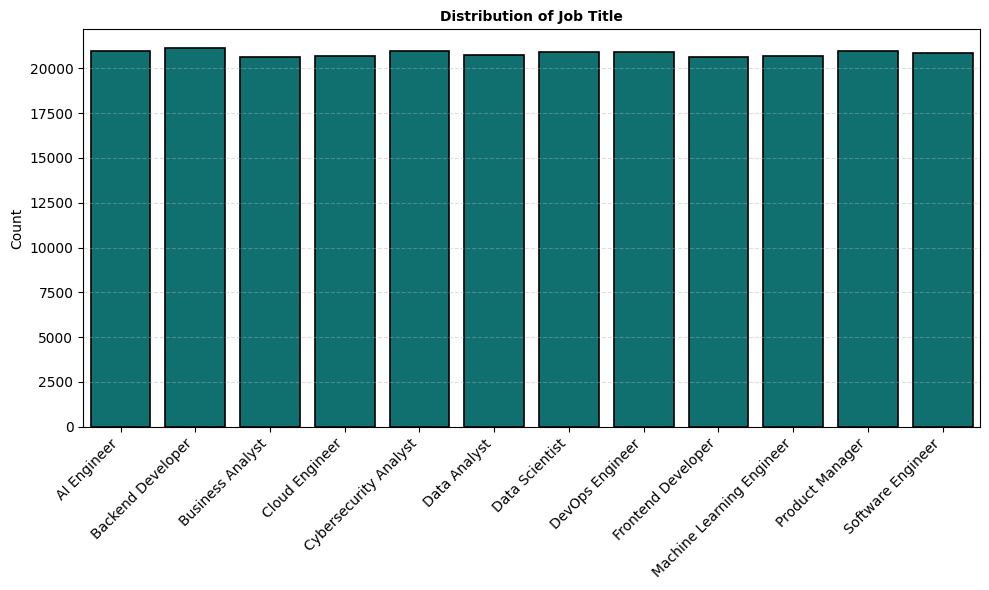


JOB_TITLE DISTRIBUTION
AI Engineer          : 20,945 (8.4%)
Backend Developer    : 21,125 (8.5%)
Business Analyst     : 20,648 (8.3%)
Cloud Engineer       : 20,686 (8.3%)
Cybersecurity Analyst : 20,959 (8.4%)
Data Analyst         : 20,722 (8.3%)
Data Scientist       : 20,890 (8.4%)
DevOps Engineer      : 20,889 (8.4%)
Frontend Developer   : 20,633 (8.3%)
Machine Learning Engineer : 20,677 (8.3%)
Product Manager      : 20,950 (8.4%)
Software Engineer    : 20,876 (8.4%)


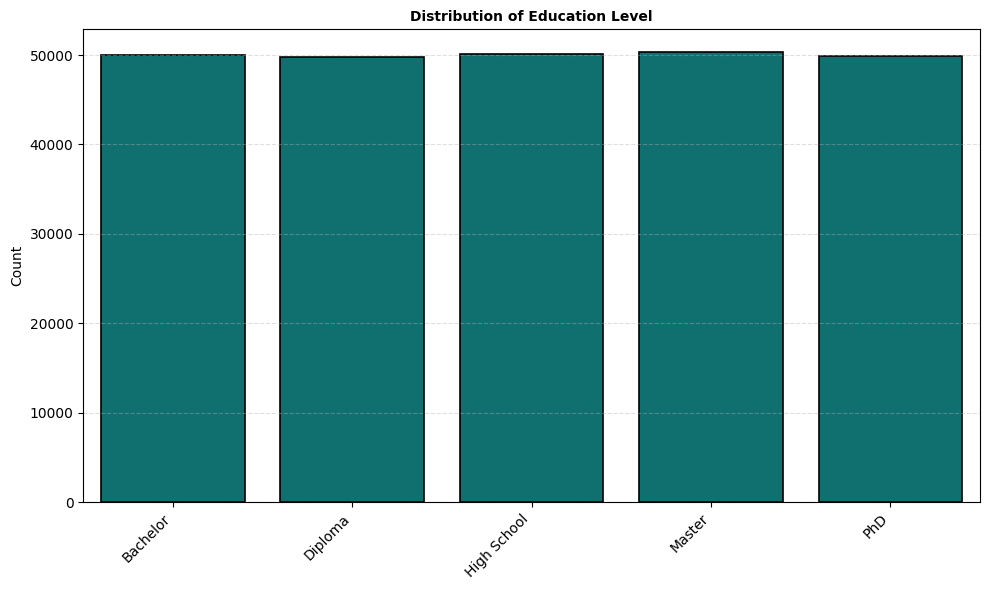


EDUCATION_LEVEL DISTRIBUTION
Bachelor             : 49,950 (20.0%)
Diploma              : 49,776 (19.9%)
High School          : 50,065 (20.0%)
Master               : 50,352 (20.1%)
PhD                  : 49,857 (19.9%)


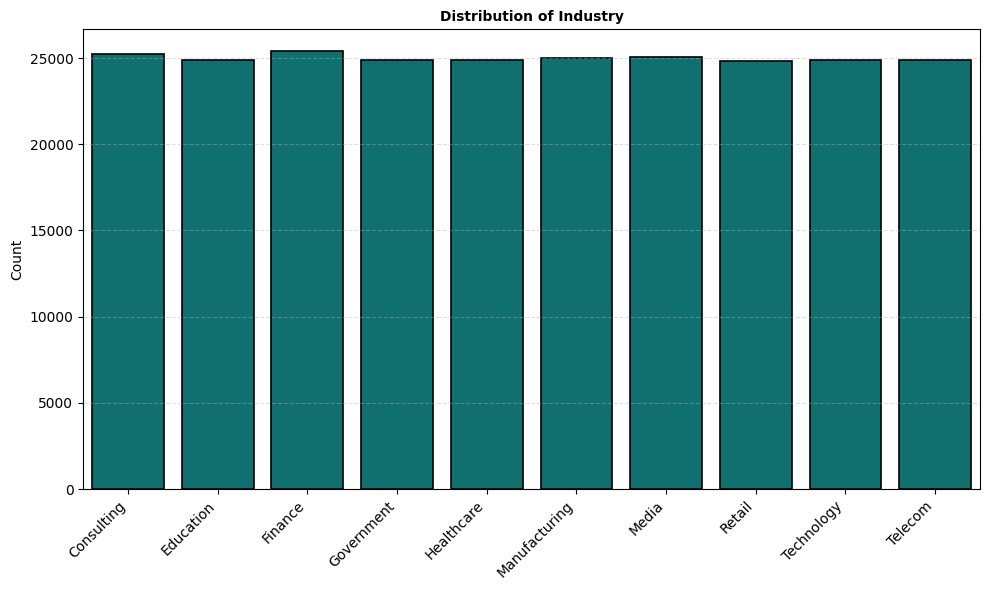


INDUSTRY DISTRIBUTION
Consulting           : 25,258 (10.1%)
Education            : 24,889 (10.0%)
Finance              : 25,393 (10.2%)
Government           : 24,901 (10.0%)
Healthcare           : 24,898 (10.0%)
Manufacturing        : 25,024 (10.0%)
Media                : 25,034 (10.0%)
Retail               : 24,841 (9.9%)
Technology           : 24,903 (10.0%)
Telecom              : 24,859 (9.9%)


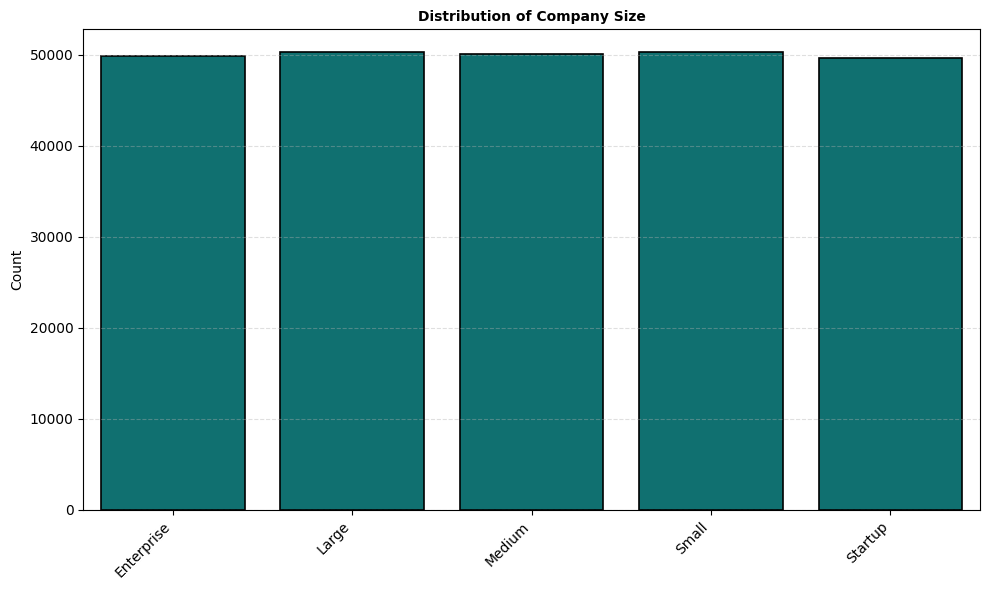


COMPANY_SIZE DISTRIBUTION
Enterprise           : 49,875 (20.0%)
Large                : 50,254 (20.1%)
Medium               : 50,027 (20.0%)
Small                : 50,235 (20.1%)
Startup              : 49,609 (19.8%)


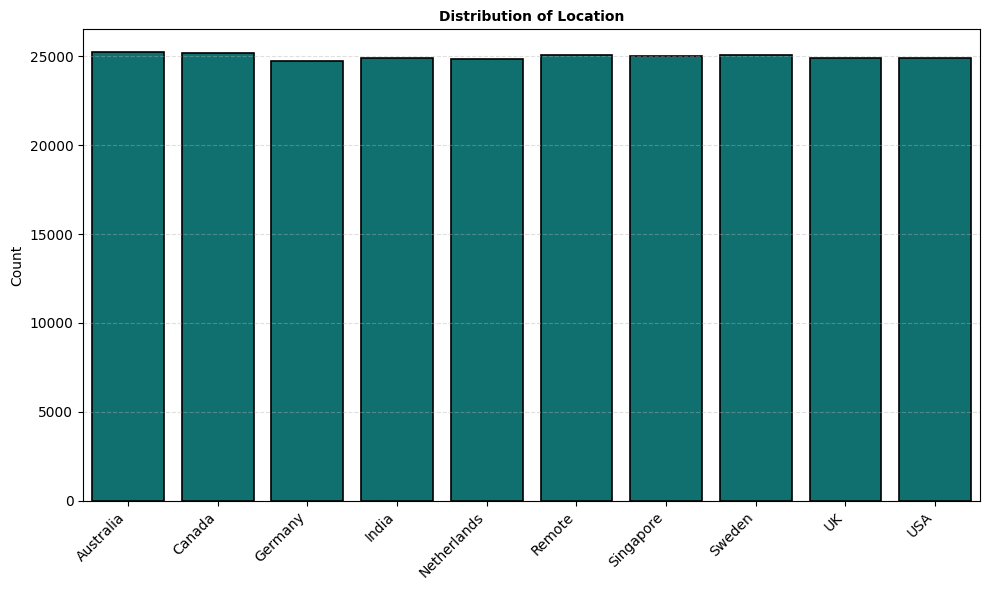


LOCATION DISTRIBUTION
Australia            : 25,258 (10.1%)
Canada               : 25,165 (10.1%)
Germany              : 24,763 (9.9%)
India                : 24,895 (10.0%)
Netherlands          : 24,861 (9.9%)
Remote               : 25,065 (10.0%)
Singapore            : 25,035 (10.0%)
Sweden               : 25,100 (10.0%)
UK                   : 24,927 (10.0%)
USA                  : 24,931 (10.0%)


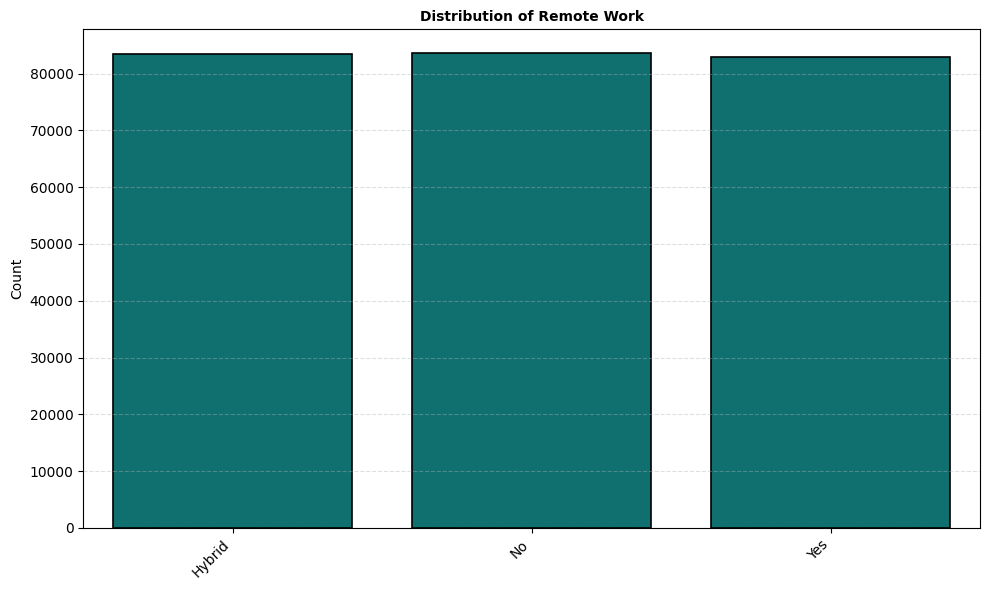


REMOTE_WORK DISTRIBUTION
Hybrid               : 83,476 (33.4%)
No                   : 83,621 (33.4%)
Yes                  : 82,903 (33.2%)


In [9]:
categoricals = ['job_title', 'education_level', 'industry', 
                'company_size', 'location', 'remote_work']
for cat in categoricals:
    plot_categorical_distribution(df, cat)

The exploratory analysis of categorical variables reveals a perfectly uniform distribution across all six features 
(job_title, education_level, industry, company_size, location, remote_work). 
Every category within each variable contains an identical number of records.
Consequently, no category is over- or under-represented. 
While this design simplifies statistical testing by ensuring equal group sizes, it limits the ability to generalize findings to actual labor market trends.

<Figure size 1200x700 with 0 Axes>

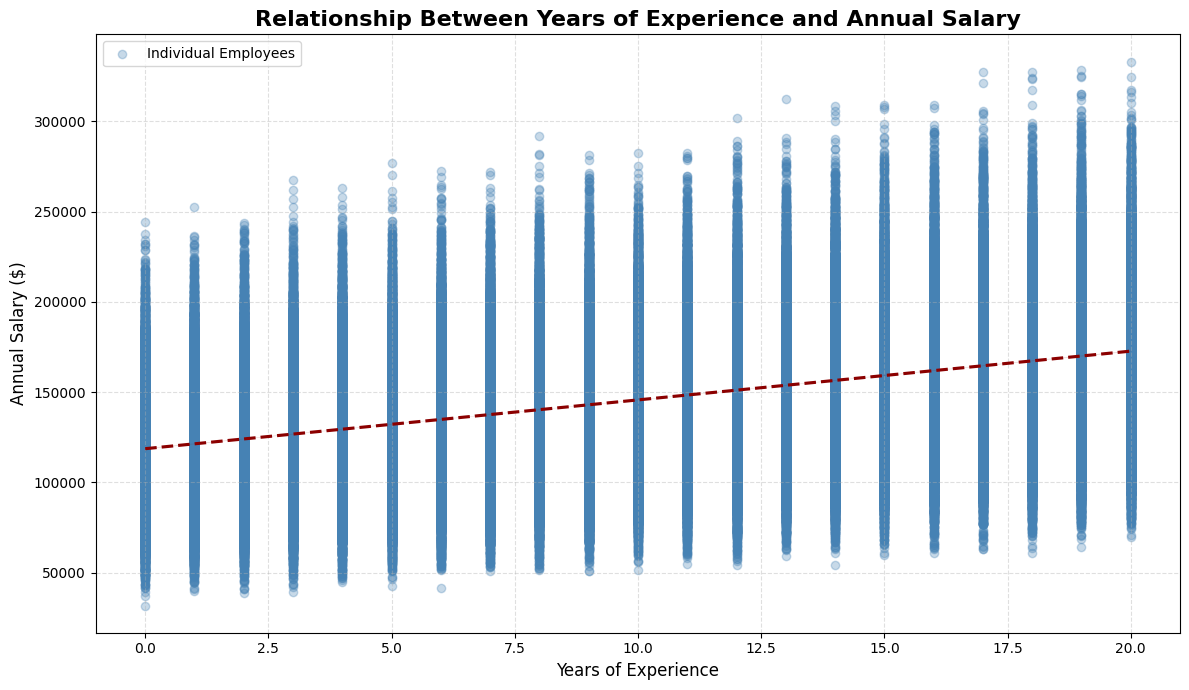

In [10]:
# Visualize the relationship between experience_years and salary. 
# Describe the shape of the relationship you observe (linear, curved, none, etc.) 
# and whether it seems consistent across the full range of experience.

# Create the figure
plt.figure(figsize=(12, 7))

# Plot: Scatter points + Regression line
plt.figure(figsize=(12, 7))
plt.scatter(
    df['experience_years'], 
    df['salary'], 
    alpha=0.3, 
    color='steelblue', 
    label='Individual Employees'
)

# Add the trend line (Linear Regression fit)
sns.regplot(
    x='experience_years', 
    y='salary', 
    data=df, 
    scatter=False, 
    color='darkred', 
    # line_width=2, 
    line_kws={'linestyle': '--'}
)

# Formatting
plt.title('Relationship Between Years of Experience and Annual Salary', fontsize=16, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

The scatter plot with a trend line visualizes the relationship between years of experience (x-axis) 
and annual salary (y-axis) for 250,000 job entries.

Each blue dot = one individual employee’s data point.
The red dashed line = linear regression trend, showing the general direction of salary growth with experience.
Key Observations:
Positive Correlation: As experience increases, salary tends to increase — the upward slope confirms this.
High Variability: At every experience level, there’s a wide spread in salaries. For example, 
at 0 years experience, salaries range from ~$30K to ~$250K. Same at 20 years — some earn ~$70K, others ~$330K. 
→ This suggests that experience alone doesn’t determine salary — other factors (education, skills, industry, location, etc.) play big roles.



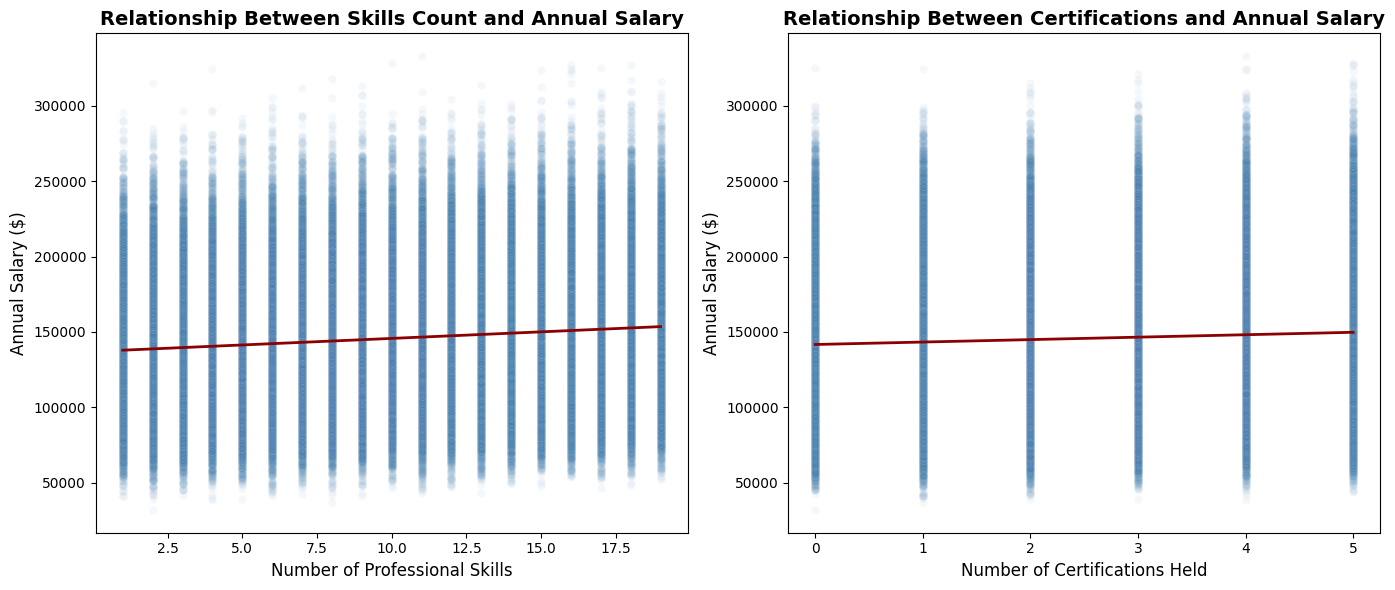

In [11]:
# Visualize the relationship between skills_count and salary, and separately between certifications and salary. 
# Do either of these appear to matter as much as experience?

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Set the rows

# --- PLOT 1: Skills Count vs Salary ---
# Scatter plot with low alpha to handle overplotting (250k points)
sns.scatterplot(data=df, x='skills_count', y='salary', alpha=0.05, ax=axes[0], color='steelblue')
# Add the trend line (regression line)
sns.regplot(data=df, x='skills_count', y='salary', scatter=False, ax=axes[0], color='darkred', line_kws={'linewidth': 2})

axes[0].set_title('Relationship Between Skills Count and Annual Salary', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Professional Skills', fontsize=12)
axes[0].set_ylabel('Annual Salary ($)', fontsize=12)

# --- PLOT 2: Certifications vs Salary ---
sns.scatterplot(data=df, x='certifications', y='salary', alpha=0.05, ax=axes[1], color='steelblue')
sns.regplot(data=df, x='certifications', y='salary', scatter=False, ax=axes[1], color='darkred', line_kws={'linewidth': 2})

axes[1].set_title('Relationship Between Certifications and Annual Salary', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Certifications Held', fontsize=12)
# No need to repeat Y-axis label if space is tight, but good for clarity
axes[1].set_ylabel('Annual Salary ($)', fontsize=12)

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

 Skills Count vs. Salary (Left Plot)
Trend Line: Slight upward slope → more skills tend to correlate with higher salary.
Implication: Having more skills doesn’t guarantee higher pay—quality, 
relevance, and context (e.g., job title, industry) matter far more.
2. Certifications vs. Salary (Right Plot)
Trend Line: Almost flat → very weak positive relationship.
Implication: Certifications alone cannpt accurately determine the salary. 

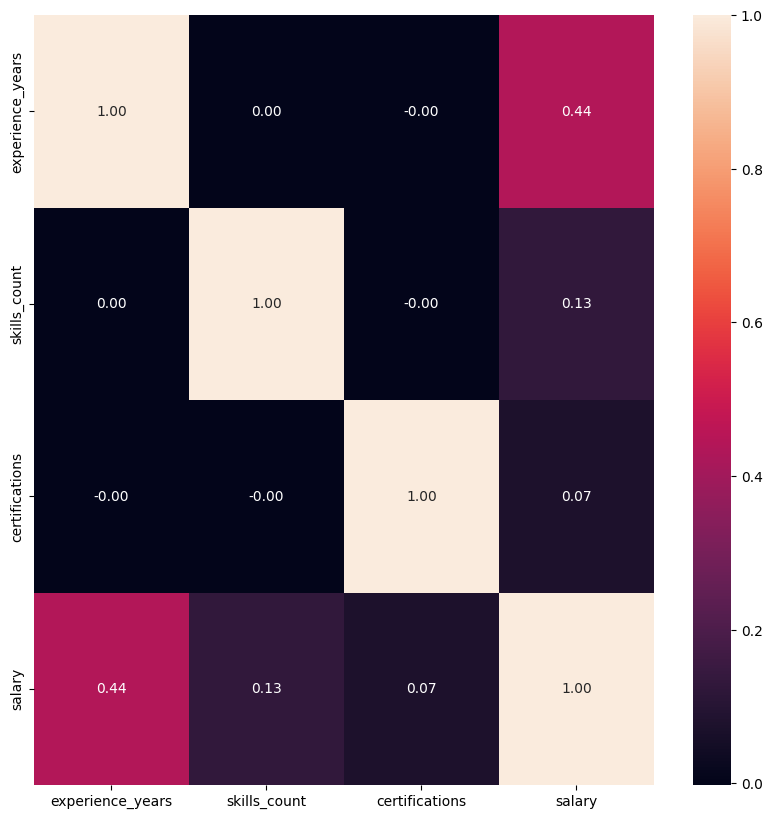

In [12]:
# Produce a single visualization that summarizes the pairwise relationships among all numeric variables 
# (including the target) at once. What does it suggest about which numeric feature is most strongly 
# associated with salary? 
# A3. Bivariate Exploration — Target vs. Categorical Features
# Select only numeric columns (include target 'salary')
# Plotting a correlation heatmap.   
# Pick the numerical columns.    

numerical_cols = df.select_dtypes(include=[float, int]).columns.to_list()   
# print(numerical_cols)  

correlation = df[numerical_cols].corr()

# Plot the correlation
plt.figure(figsize=(10,10))

sns.heatmap(correlation, annot=True, fmt='.2f')
plt.show()

Which numeric feature is most strongly associated with salary?

experience_years — with a correlation of 0.44 — is clearly the strongest numeric predictor of salary in this dataset.

It’s more than 3x stronger than skills_count (0.13)
And 6x stronger than certifications (0.07)
This confirms what we saw in the scatter plots: years of professional experience is the dominant numeric driver of salary.

For predicting salary numerically, experience_years is your most powerful single feature.
Skills and certifications add little predictive value on their own — they may help in combination with other variables (like job title or education), but alone, they’re weak signals.



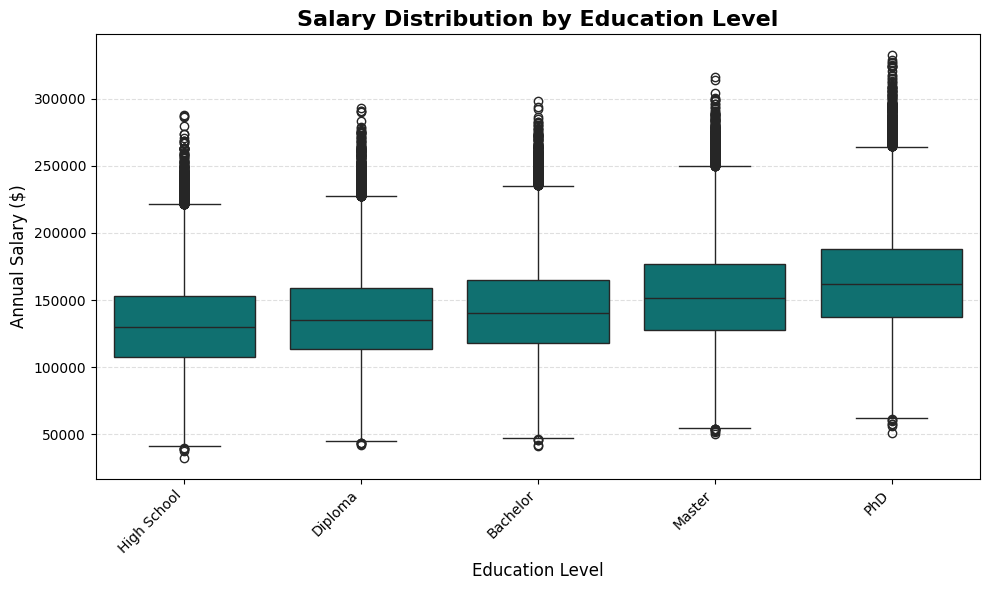


--- Median Salary by Education Level ---
High School : $129,663
Diploma     : $135,283
Bachelor    : $140,632
Master      : $151,396
PhD         : $162,005


In [13]:
# Compare the salary distribution across the different education_level categories. 
# Does salary appear to increase consistently with education level,
# or is the pattern less clear?
# 2. Define the order of education levels (ordinal nature)
# This ensures the x-axis is logical, not alphabetical
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

# 3. Create the plot
plt.figure(figsize=(10, 6))

# 4. Generate the boxplot
sns.boxplot(
    data=df,
    x='education_level',
    y='salary',
    order=education_order,  # Enforce logical order
    hue=None,
    legend=False,
    color='teal'
)

# 5. Add titles and labels
plt.title('Salary Distribution by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)

# 6. Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# 7. Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 8. Optional: Print median salaries to the console for exact comparison
print("\n--- Median Salary by Education Level ---")
medians = df.groupby('education_level')['salary'].median()
# Sort by our defined order
medians = medians.reindex(education_order)
for level, salary in medians.items():
    print(f"{level:12}: ${salary:,.0f}")


Salary does NOT increase consistently with education level.

While the average (median) rises with higher degrees, the overlap is so large that you cannot predict an individual's salary based on education alone.

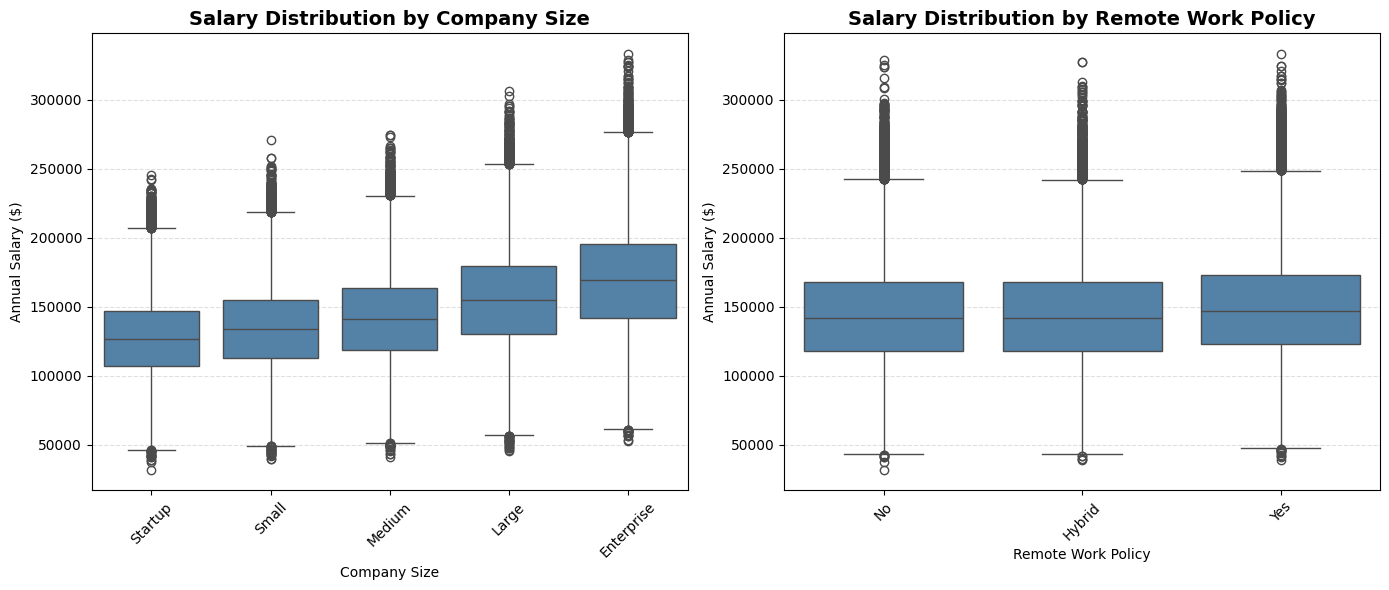


--- Median Salary by Company Size ---
Startup   : $126,660
Small     : $134,001
Medium    : $140,861
Large     : $154,981
Enterprise: $168,958

--- Median Salary by Remote Work Policy ---
No        : $141,630
Hybrid    : $141,672
Yes       : $147,153


In [14]:
# Compare the salary distribution across company_size categories and 
# separately across remote_work categories. Summarize any noticeable differences.

# Define logical order for company_size (ordinal)
company_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
remote_order = ['No', 'Hybrid', 'Yes']

# Create a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Company Size ---
sns.boxplot(
    data=df,
    x='company_size',
    y='salary',
    order=company_order,
    ax=axes[0],
    hue=None,
    legend=False,
    color='steelblue'
)
axes[0].set_title('Salary Distribution by Company Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company Size')
axes[0].set_ylabel('Annual Salary ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Remote Work ---
sns.boxplot(
    data=df,
    x='remote_work',
    y='salary',
    order=remote_order,
    ax=axes[1],
    hue=None,
    legend=False,
    color='steelblue'
)
axes[1].set_title('Salary Distribution by Remote Work Policy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Remote Work Policy')
axes[1].set_ylabel('Annual Salary ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Optional: Print median salaries for exact comparison
print("\n--- Median Salary by Company Size ---")
medians_company = df.groupby('company_size')['salary'].median().reindex(company_order)
for size, salary in medians_company.items():
    print(f"{size:10}: ${salary:,.0f}")

print("\n--- Median Salary by Remote Work Policy ---")
medians_remote = df.groupby('remote_work')['salary'].median().reindex(remote_order)
for policy, salary in medians_remote.items():
    print(f"{policy:10}: ${salary:,.0f}")

Company size has a clear, positive relationship with salary — larger companies pay more on average, with Startups showing high volatility.
Remote work policy has virtually no impact on salary — the distributions are nearly identical across “No,” “Hybrid,” and “Yes.”

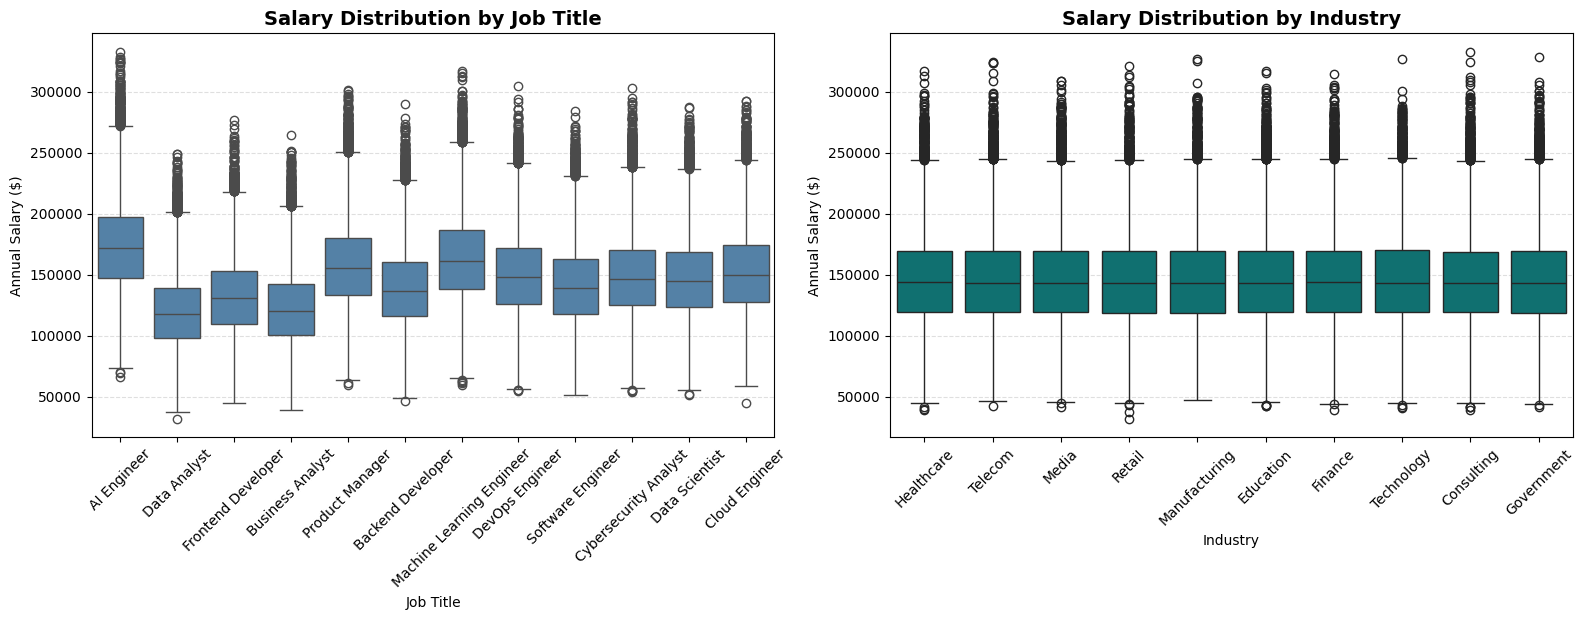


  MEDIAN SALARIES BY JOB TITLE (Sorted High to Low)
 1. AI Engineer               : $171,674
 2. Machine Learning Engineer : $160,933
 3. Product Manager           : $155,656
 4. Cloud Engineer            : $150,005
 5. DevOps Engineer           : $148,021
 6. Cybersecurity Analyst     : $146,737
 7. Data Scientist            : $145,232
 8. Software Engineer         : $139,432
 9. Backend Developer         : $136,678
10. Frontend Developer        : $130,619
11. Business Analyst          : $120,562
12. Data Analyst              : $118,080

  MEDIAN SALARIES BY INDUSTRY (Sorted High to Low)
 1. Healthcare           : $143,998
 2. Finance              : $143,858
 3. Education            : $143,627
 4. Media                : $143,592
 5. Telecom              : $143,380
 6. Technology           : $143,359
 7. Retail               : $143,234
 8. Consulting           : $143,202
 9. Government           : $143,176
10. Manufacturing        : $143,120



In [15]:
# Compare the salary distribution across job_title and separately across industry. Which job titles or 
# industries stand out as paying noticeably more or less, and are there wide spreads within any single category?
# Create a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Job Title (No Manual Order) ---
sns.boxplot(
    data=df,
    x='job_title',
    y='salary',
    ax=axes[0],
    hue=None,
    legend=False,
    color='steelblue'
)
axes[0].set_title('Salary Distribution by Job Title', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Job Title')
axes[0].set_ylabel('Annual Salary ($)')
# Use plt.xticks on the specific axis for better stability
axes[0].tick_params(axis='x', rotation=45)  # Removed ha='right' to prevent errors
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Industry  ---
sns.boxplot(
    data=df,
    x='industry',
    y='salary',
    ax=axes[1],
    hue=None,
    legend=False,
    color='teal'
)
axes[1].set_title('Salary Distribution by Industry', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Industry')
axes[1].set_ylabel('Annual Salary ($)')
axes[1].tick_params(axis='x', rotation=45)  # Lable angle
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Adjust layout to prevent label cutting
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.show()

# --- Sorted Medians ---
print("\n" + "="*60)
print("  MEDIAN SALARIES BY JOB TITLE (Sorted High to Low)")
print("="*60)
medians_job = df.groupby('job_title')['salary'].median().sort_values(ascending=False)
for i, (title, salary) in enumerate(medians_job.items(), 1):
    print(f"{i:2}. {title:25} : ${salary:,.0f}")

print("\n" + "="*60)
print("  MEDIAN SALARIES BY INDUSTRY (Sorted High to Low)")
print("="*60)
medians_ind = df.groupby('industry')['salary'].median().sort_values(ascending=False)
for i, (ind, salary) in enumerate(medians_ind.items(), 1):
    print(f"{i:2}. {ind:20} : ${salary:,.0f}")
print("="*60 + "\n")

Job titles show clear pay hierarchies: AI Engineers and ML Engineers earn significantly more than Data Analysts or Business Analysts.
Industries show NO meaningful differences: All hover around $143K.

BUT — within every category (job title OR industry), there are WIDE spreads. This means:

Your role matters most for salary potential.
Your industry matters less (but still influences the ceiling via budget).
Variability is huge: Two people with the same title/industry can earn $100K+ apart due to experience, location, or negotiation.

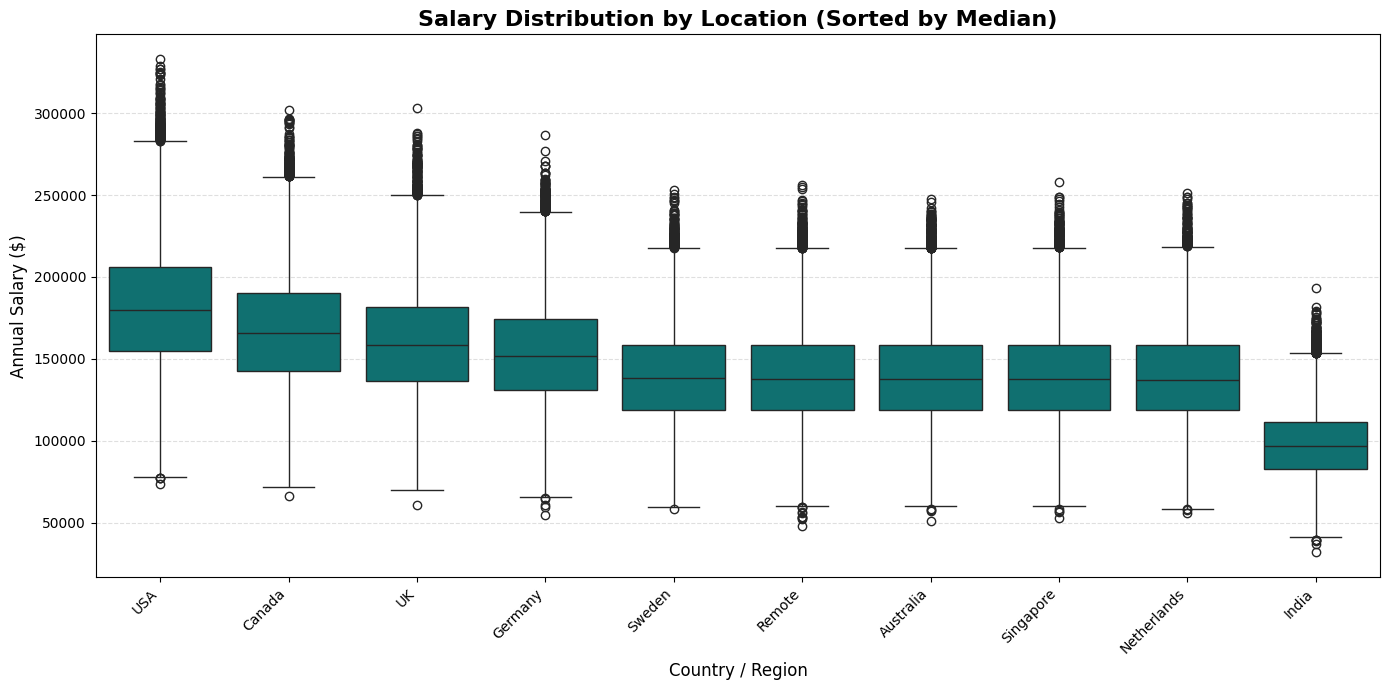


  MEDIAN SALARIES BY LOCATION (Sorted High to Low)
 1. USA             : $179,647
 2. Canada          : $165,474
 3. UK              : $158,191
 4. Germany         : $151,538
 5. Sweden          : $138,033
 6. Remote          : $137,836
 7. Australia       : $137,754
 8. Singapore       : $137,699
 9. Netherlands     : $137,356
10. India           : $96,501


In [16]:
# Compare the salary distribution across location. Are there visible differences by country/region, and how 
# would you characterize the spread within each?

# Sort locations by median salary (high to low) for the plot
location_order = df.groupby('location')['salary'].median().sort_values(ascending=False).index

# Create the plot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x='location',
    y='salary',
    order=location_order,  # Sort by median
    hue=None,
    legend=False,
    color='teal'
)

# Title and labels
plt.title('Salary Distribution by Location (Sorted by Median)', fontsize=16, fontweight='bold')
plt.xlabel('Country / Region', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# --- Sorted Medians ---
print("\n" + "="*60)
print("  MEDIAN SALARIES BY LOCATION (Sorted High to Low)")
print("="*60)
medians_loc = df.groupby('location')['salary'].median().sort_values(ascending=False)
for i, (loc, salary) in enumerate(medians_loc.items(), 1):
    print(f"{i:2}. {loc:15} : ${salary:,.0f}")


Yes, there are VISIBLE and SIGNIFICANT differences by location.

USA, UK, Germany, and Singapore pay the most.
India and Australia pay less (on average).
Remote is a wildcard: it sits in the middle but has the widest spread of all.

Spread Characterization:

Higher-paying locations (USA, UK) have wider spreads due to city/rural gaps and role diversity.
Lower-paying locations (India) have moderate spreads.
Remote has the most unpredictable spread (mix of global rates).
This confirms that location is a strong predictor of salary.



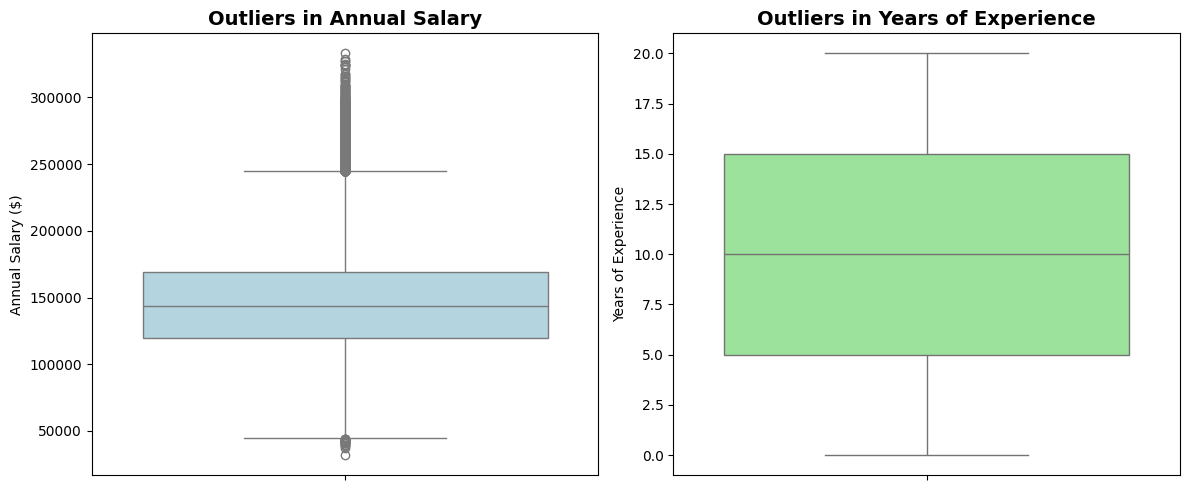


  OUTLIER COUNT

[SALARY]
  Normal Range:  $44,157  to  $244,693
  Outliers:      2336 (0.93% of data)
  Sample Low:    $31,867
  Sample High:   $333,046

[EXPERIENCE (Years)]
  Normal Range:  $-10  to  $30
  Outliers:      0 (0.00% of data)




In [17]:
# Identify potential outliers in salary and in at least one numeric feature using an appropriate visualization. 
# How many extreme values do you find, and would you treat them as data errors or as legitimate high/low values?

df['experience_years'] = df['experience_years'].abs() # Remove negative years of experience

# Create a 1x2 plot: Salary vs. Experience
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Salary Outliers
sns.boxplot(data=df, y='salary', ax=axes[0], color='lightblue')
axes[0].set_title('Outliers in Annual Salary', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Annual Salary ($)')

# Plot 2: Experience Outliers
sns.boxplot(data=df, y='experience_years', ax=axes[1], color='lightgreen')
axes[1].set_title('Outliers in Years of Experience', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Years of Experience')

plt.tight_layout()
plt.show()

# --- Outlier Count & Stats  ---
print("\n" + "="*60)
print("  OUTLIER COUNT")
print("="*60)

def count_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    count = len(outliers)
    pct = (count / len(series)) * 100
    print(f"\n[{name}]")
    print(f"  Normal Range:  ${lower:,.0f}  to  ${upper:,.0f}")
    print(f"  Outliers:      {count} ({pct:.2f}% of data)")
    if count > 0:
        print(f"  Sample Low:    ${outliers.min():,.0f}")
        print(f"  Sample High:   ${outliers.max():,.0f}")

count_outliers(df['salary'], 'SALARY')
count_outliers(df['experience_years'], 'EXPERIENCE (Years)')

print("\n" + "="*60 + "\n")

We found 2,336 salary outliers (0.93% of data).

High outliers ($333K+$) are legitimate top earners. Top executives.

Low outliers ($31K) are likely legitimate (entry-level/interns).

We found 0 experience outliers.

<Figure size 1400x700 with 0 Axes>

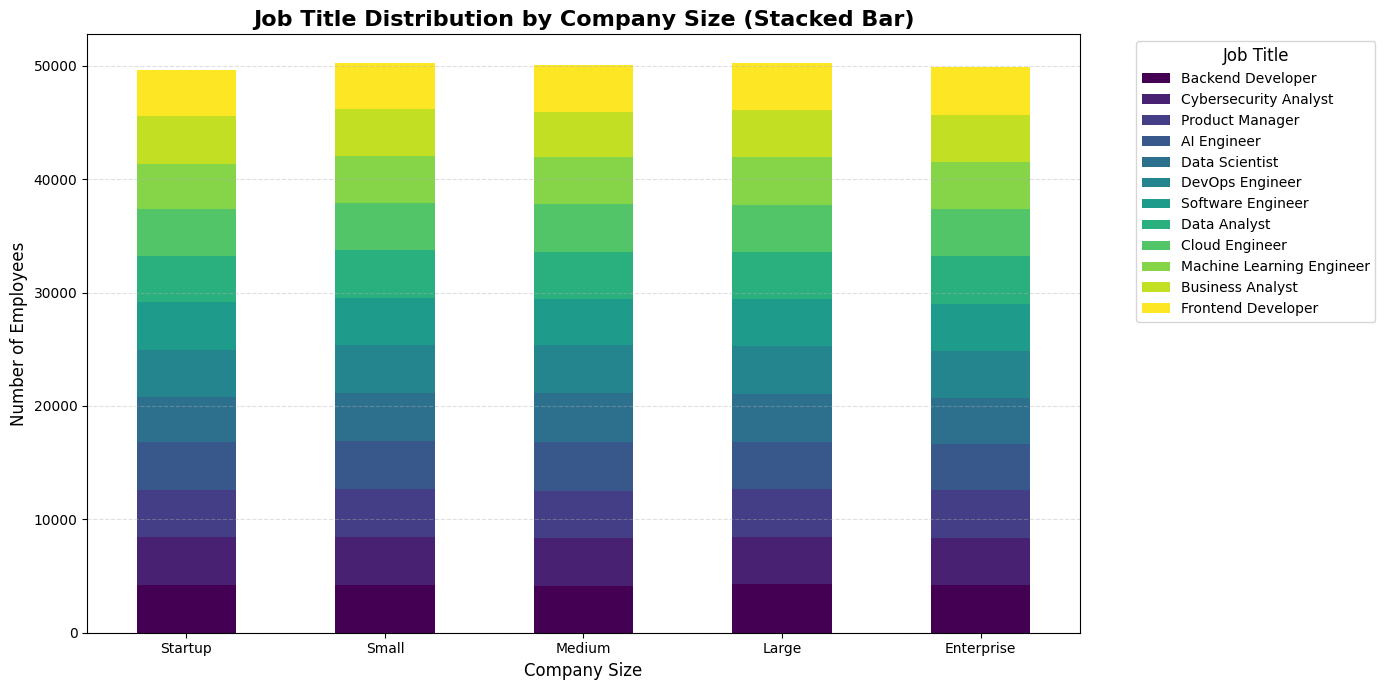

In [18]:
# Define logical order for company_size
company_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']

# Group by company_size and job_title, then count
pivot_data = df.groupby(['company_size', 'job_title']).size().unstack(fill_value=0)

# Reorder columns by total count (most common jobs first)
job_order = pivot_data.sum().sort_values(ascending=False).index.tolist()
pivot_data = pivot_data[job_order]

# Reorder rows by company_size
pivot_data = pivot_data.reindex(company_order)

# Plot
plt.figure(figsize=(14, 7))
pivot_data.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')

# Title and labels
plt.title('Job Title Distribution by Company Size (Stacked Bar)', fontsize=16, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Job Title', fontsize=10, title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Part B — Testing the Relationship Between Target and Features
# For each question below, formally test whether a statistically significant relationship exists 
# between salary and the specified feature(s). 
# You must select the test yourself based on the variable types involved and the assumptions 
# the data satisfy (or violate).
# B1. Numeric Features vs. Salary
# 1. Test whether there is a statistically significant relationship between 
# experience_years and salary. Check whatever assumptions are relevant to the test you choose 
# before running it, and justify your final choice of test based on those checks.



#### Null Hypothesis (H₀): 
There is no linear relationship between years of experience and annual salary (ρ = 0).

Alternative Hypothesis (H₁): There is a linear relationship between years of experience and annual salary (ρ ≠ 0).

#### Test Used: Pearson Correlation Test.
Significance Level (α): 0.05.

#### Decision Rule:

- If p-value < 0.05 → Reject H₀ (relationship exists).

- If p-value ≥ 0.05 → Fail to reject H₀ (no evidence of relationship).

In [21]:
# ---  Pearson Correlation Test ---
r, p_value = pearsonr(df['experience_years'], df['salary'])
r_squared = r ** 2

print("\n" + "="*60)
print("  HYPOTHESIS TEST RESULTS")
print("="*60)
print(f"Null Hypothesis (H₀): ρ = 0 (No linear relationship)")
print(f"Alternative Hypothesis (H₁): ρ ≠ 0 (Linear relationship exists)")
print("-"*60)
print(f"Correlation Coefficient (r): {r:.3f}")
print(f"Effect Size (R²): {r_squared:.3f} ({r_squared*100:.1f}% of variance explained)")
print(f"p-value: {p_value:.4e}")
print("-"*60)

# Decision
alpha = 0.05
if p_value < alpha:
    print(f"✅ RESULT: p-value ({p_value:.4e}) < {alpha}")
    print("   => REJECT Null Hypothesis (H₀).")
    print("   => CONCLUSION: There IS a statistically significant linear relationship")
    print("      between 'experience_years' and 'salary'.")
else:
    print(f"⚠️ RESULT: p-value ({p_value:.4e}) >= {alpha}")
    print("   => FAIL TO REJECT Null Hypothesis (H₀).")
    print("   => CONCLUSION: No sufficient evidence of a linear relationship.")

print("="*60 + "\n")


  HYPOTHESIS TEST RESULTS
Null Hypothesis (H₀): ρ = 0 (No linear relationship)
Alternative Hypothesis (H₁): ρ ≠ 0 (Linear relationship exists)
------------------------------------------------------------
Correlation Coefficient (r): 0.438
Effect Size (R²): 0.192 (19.2% of variance explained)
p-value: 0.0000e+00
------------------------------------------------------------
✅ RESULT: p-value (0.0000e+00) < 0.05
   => REJECT Null Hypothesis (H₀).
   => CONCLUSION: There IS a statistically significant linear relationship
      between 'experience_years' and 'salary'.



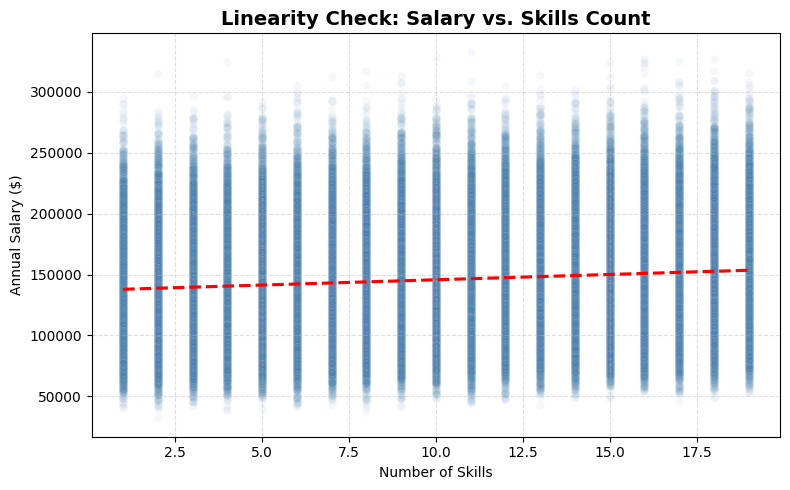


  HYPOTHESIS TEST RESULTS: Skills Count vs. Salary
Null Hypothesis (H₀): ρ = 0 (No linear relationship)
Alternative Hypothesis (H₁): ρ ≠ 0 (Linear relationship exists)
----------------------------------------------------------------------
Correlation Coefficient (r): 0.127
Effect Size (R²): 0.016 (1.6% of variance explained)
p-value: 0.0000e+00
----------------------------------------------------------------------
✅ RESULT: p-value (0.0000e+00) < 0.05
   => REJECT Null Hypothesis (H₀).
   => CONCLUSION: There IS a statistically significant linear relationship
      between 'skills_count' and 'salary'.



In [23]:
# Test whether there is a statistically significant relationship between skills_count and salary.
# Null (H₀)	There is NO linear relationship between skills_count and salary.	ρ = 0
# Alternative (H₁)	There IS a linear relationship between skills_count and salary.	ρ ≠ 0

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='skills_count', y='salary', alpha=0.05, color='steelblue')
sns.regplot(data=df, x='skills_count', y='salary', scatter=False, color='red', line_kws={'linestyle': '--'})
plt.title('Linearity Check: Salary vs. Skills Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Skills')
plt.ylabel('Annual Salary ($)')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- Pearson Correlation Test ---
r, p_value = pearsonr(df['skills_count'], df['salary'])
r_squared = r ** 2

print("\n" + "="*70)
print("  HYPOTHESIS TEST RESULTS: Skills Count vs. Salary")
print("="*70)
print(f"Null Hypothesis (H₀): ρ = 0 (No linear relationship)")
print(f"Alternative Hypothesis (H₁): ρ ≠ 0 (Linear relationship exists)")
print("-"*70)
print(f"Correlation Coefficient (r): {r:.3f}")
print(f"Effect Size (R²): {r_squared:.3f} ({r_squared*100:.1f}% of variance explained)")
print(f"p-value: {p_value:.4e}")
print("-"*70)

# Decision
alpha = 0.05
if p_value < alpha:
    print(f"✅ RESULT: p-value ({p_value:.4e}) < {alpha}")
    print("   => REJECT Null Hypothesis (H₀).")
    print("   => CONCLUSION: There IS a statistically significant linear relationship")
    print("      between 'skills_count' and 'salary'.")
else:
    print(f"⚠️ RESULT: p-value ({p_value:.4e}) >= {alpha}")
    print("   => FAIL TO REJECT Null Hypothesis (H₀).")
    print("   => CONCLUSION: No sufficient evidence of a linear relationship.")

print("="*70 + "\n")